In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from Preprocess import preprocess_data_window
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
#filtered_time = pd.read_csv("filtered_time_normalized.csv", index_col=0)
#data_orig = data_orig.loc[filtered_time.index]


#Testing 182 lag events for classical-only model: 
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time,
    data_orig,
    n_previous_events=20
)

X shape:  (2822, 126)
y shape:  (2822,)


In [3]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("MAE XGBoost Error:", XGBoost_Error_MAE)

[I 2026-03-24 22:12:01,445] A new study created in memory with name: no-name-294b6189-240a-48df-9a4d-6d9d3d987745
[I 2026-03-24 22:12:05,188] Trial 0 finished with value: 16610.68673179424 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 16610.68673179424.
[I 2026-03-24 22:12:06,234] Trial 1 finished with value: 17696.51490712202 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 16610.68673179424.
[I 2026-03-24 22:12:08,198] Trial 2 finished with value: 16910.393565186347 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 16610.68673179424.
[I 2026-03-24 22:12:09,208] Trial 3 finished with value: 17501.307795621797 and pa

Optimal Parameters: {'learning_rate': 0.031580904152223435, 'max_depth': 5, 'subsample': 0.8407951398015077, 'colsample_bytree': 0.8685684874126708}
XGBoost Error: 15156.766613104091
MAE XGBoost Error: 11353.133382881637


In [4]:
# XGBoost with sample weighting for long inter-event times

# Sample weights — upweight top 25% longest intervals 3x
sample_weights_train = np.where(
    y_train > np.percentile(y_train, 75),
    3.0,
    1.0
)

# Tuning XGBoost through the Optuna library
def objective(trial):
    XGBoost = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        random_state=42
    )
    XGBoost.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,  # added
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    predictions = XGBoost.predict(X_val)
    RMSE = root_mean_squared_error(y_val, predictions)
    return RMSE

# Finding the parameters that minimize the squared error
optimization = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
optimization.optimize(objective, n_trials=30)

optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

# Running XGBoost with optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,  # added
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Evaluation
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost RMSE:", XGBoost_Error)

XGBoost_MAE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_MAE
print("MAE XGBoost Error:", XGBoost_Error_MAE)

[I 2026-03-24 22:13:12,239] A new study created in memory with name: no-name-b7646570-d2f2-4d50-b5f3-64810d62118d
[I 2026-03-24 22:13:15,049] Trial 0 finished with value: 17004.195971210378 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 17004.195971210378.
[I 2026-03-24 22:13:16,112] Trial 1 finished with value: 18824.192660394205 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 17004.195971210378.
[I 2026-03-24 22:13:18,190] Trial 2 finished with value: 17412.79869759003 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 17004.195971210378.
[I 2026-03-24 22:13:19,423] Trial 3 finished with value: 18751.425497801425 an

Optimal Parameters: {'learning_rate': 0.016701255452107315, 'max_depth': 5, 'subsample': 0.6858734012810879, 'colsample_bytree': 0.8090493002947068}
XGBoost RMSE: 15628.101251503851
MAE XGBoost Error: 11689.138384955751


2254    87450.0
3912    58215.0
2637    88560.0
2600    31005.0
2268    36825.0
         ...   
1415    81705.0
2923    41475.0
2555    48180.0
2503    87375.0
2592    91905.0
Name: time_to_next_ev_hr, Length: 565, dtype: float64
[63474.543 57562.76  80174.67  43926.67  71785.28  69759.9   63296.17
 58254.77  59075.25  49560.594 87186.48  72295.125 42880.38  67389.516
 61800.727 52657.69  77843.93  60508.273 80515.99  83367.84  32290.719
 52005.984 56705.387 69053.664 81281.07  56184.1   46479.63  51807.85
 43245.78  63682.49  79578.45  70916.51  71189.34  64819.047 38446.06
 51682.67  71931.85  52974.68  65986.63  52941.6   56515.066 51930.062
 81133.16  57612.766 56843.594 75276.76  66422.836 83853.09  52869.492
 56218.363 71800.73  50407.22  61930.926 53956.29  70106.95  57103.723
 73747.93  75274.11  41264.01  52695.457 84702.38  55116.363 74687.8
 56356.26  44049.84  57874.16  60071.734 66615.44  54374.523 44535.24
 62513.984 64874.09  71644.94  58523.914 80458.984 80392.88  74414

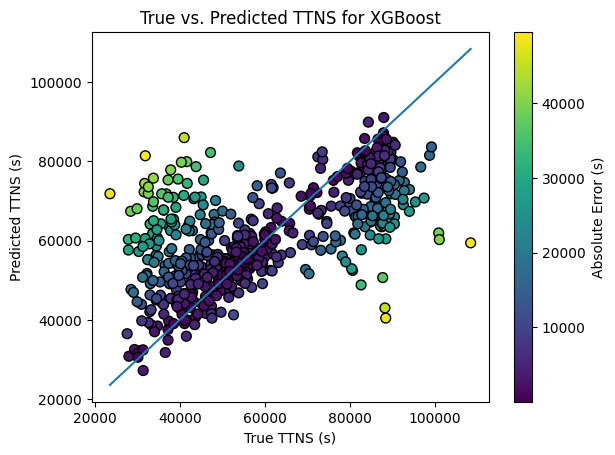

In [5]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

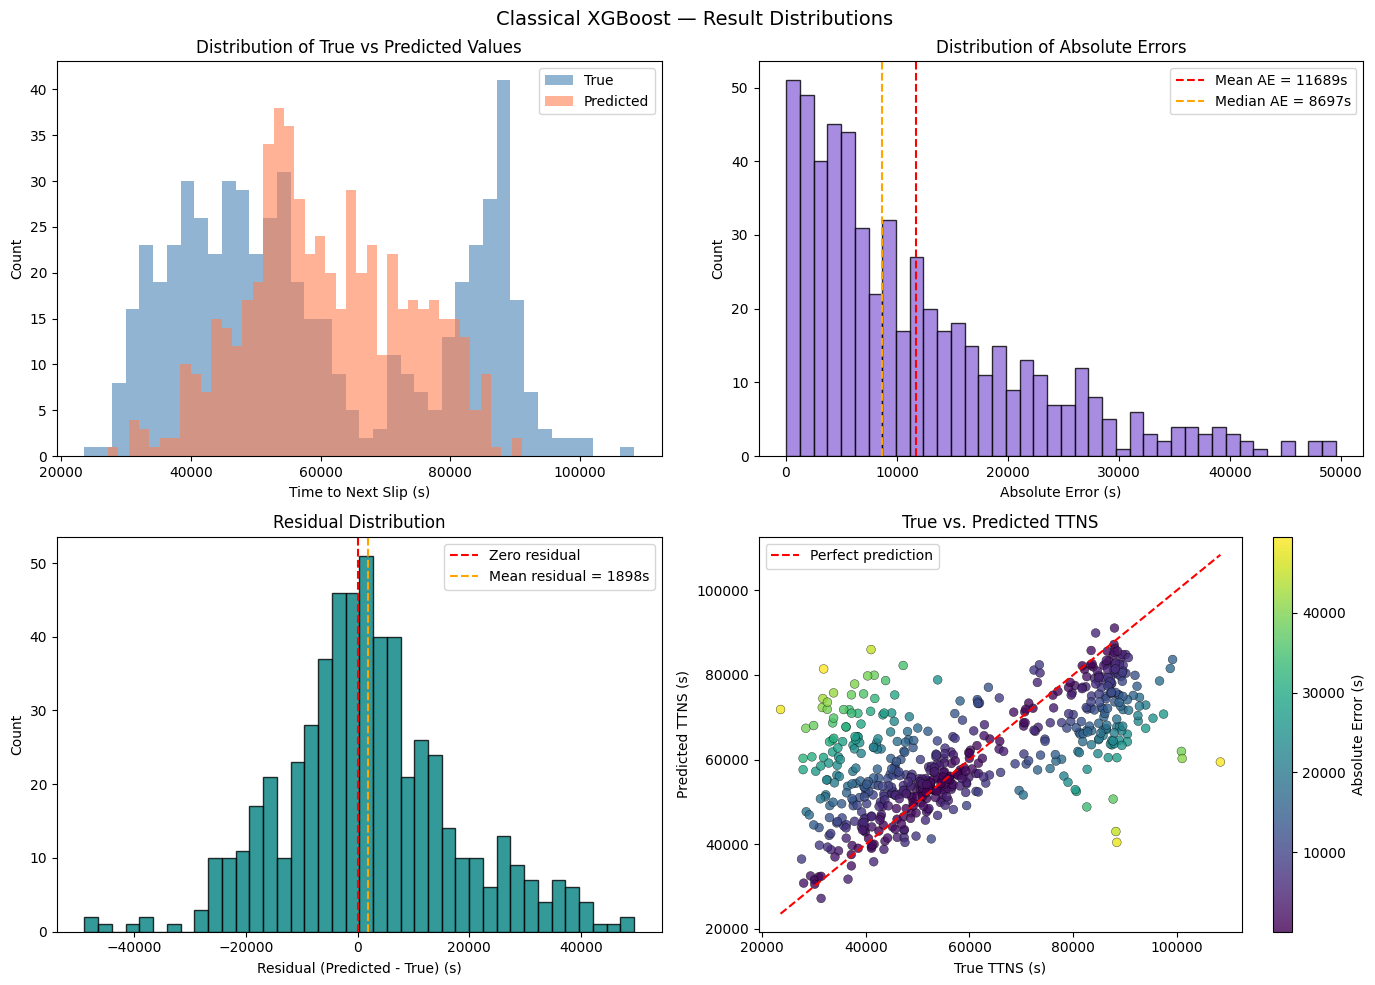

MAE:            11689.14s
Median AE:      8697.23s
RMSE:           15628.10s
R2:             0.3979
Max error:      49508.91s
% within 5000s: 32.7%
% within 9000s: 51.9%


: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Data distribution plot for Classical XGBoost ─────────────────────────────
y_test_secs   = y_test
XG_pred_secs  = XGBoost_Prediction

absolute_errors = np.abs(XG_pred_secs - y_test_secs)
residuals       = XG_pred_secs - y_test_secs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Classical XGBoost — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted values ────────────────────────
axes[0, 0].hist(y_test_secs, bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(XG_pred_secs, bins=40, alpha=0.6, color='coral', label='Predicted')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ─────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(), color='red', linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted - True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 4: True vs Predicted scatter ───────────────────────────────────────
sc = axes[1, 1].scatter(y_test_secs, XG_pred_secs,
                         c=absolute_errors, cmap='viridis',
                         s=40, edgecolors='black', linewidths=0.3, alpha=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"MAE:            {mean_absolute_error(y_test_secs, XG_pred_secs):.2f}s")
print(f"Median AE:      {np.median(absolute_errors):.2f}s")
print(f"RMSE:           {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R2:             {r2_score(y_test_secs, XG_pred_secs):.4f}")
print(f"Max error:      {absolute_errors.max():.2f}s")
print(f"% within 5000s: {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9000s: {(absolute_errors < 9000).mean()*100:.1f}%")

In [ ]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
plt.xticks(fontsize=14)   # <-- Increase x-axis label size
plt.yticks(fontsize=12)
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers", fontsize=20)
plt.ylabel("Mean Absolute SHAP Value", fontsize=18)
plt.xlabel("Feature", fontsize=18)
plt.show()
